# **Modelul de creștere al populației**

Proiectul va utiliza un model matematic simplificat de creștere a populației împărțită pe clase de vârstă, folosind o matrice de tranziție pentru a simula evoluția populației în funcție de ratele de naștere, de supraviețuire și
structura inițială a populației. În plus, vom analiza ratele de creștere calculate folosind valorile proprii ale matricei de tranziție. Comparația va fi făcută între metoda de calcul a valorii proprii directă (numpy.linalg.eig) și metoda puterii.





Importăm bibliotecile necesare pentru manipularea matricilor, calcularea valorilor proprii, vizualizare și gestionarea datelor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.linalg import eig

# Definirea modelului de creștere al populației
Definirea funcției care implementează modelul de creștere al populației utilizând matrici de tranziție pentru clasele de vârstă.

In [2]:
def apply_population_model(max_age, age_classes, birth_rates, survival_probs, initial_population, years):
    # Determinăm numărul de clase de vârstă (n)
    n = age_classes

    # Validăm dacă lungimea listelor de rate ale natalității și probabilităților de supraviețuire sunt corecte
    if len(birth_rates) != n or len(survival_probs) != n - 1:
        raise ValueError("Lungimea ratei natalității sau a probabilităților de supraviețuire nu corespunde numărului de clase de vârstă.")

    # Creăm matricea de tranziție A (matricea care modelează dinamica populației)
    A = np.zeros((n, n))

    # Setăm rata natalității în prima linie a matricei
    A[0, :] = birth_rates

    # Setăm probabilitățile de supraviețuire pe subdiagonala matricei
    for i in range(1, n):
        A[i, i - 1] = survival_probs[i - 1]  # Se consideră doar p_i * x[i-1] pentru supraviețuirea între clase

    # Vectorul de populație inițială
    x = np.array(initial_population)

    # Simularea pentru un număr specificat de ani
    time_steps = years // (max_age // n)  # Calculăm pașii de timp pe baza duratei fiecărei clase de vârstă
    absolute_populations = [x.copy()]

    # Aplicația matricei de tranziție pentru a obține populația de fiecare dată
    for _ in range(time_steps):
        x = A @ x  # Se înmulțește matricea cu vectorul pentru a actualiza populația
        absolute_populations.append(x.copy())

    # Normalizăm populația pentru a obține procente
    x_normalized = absolute_populations[0] / np.sum(absolute_populations[0])
    percentage_populations = [x_normalized]

    # Continuăm cu normalizarea pentru toate populațiile absolute
    for abs_pop in absolute_populations[1:]:
        x_normalized = abs_pop / np.sum(abs_pop)
        percentage_populations.append(x_normalized)

    absolute_populations = np.array(absolute_populations)
    percentage_populations = np.array(percentage_populations)

    # Returnăm populațiile absolute și procentajele
    return absolute_populations, percentage_populations, A

# Implementarea metodei puterii eficient pentru determinarea valorilor proprii

In [3]:
def power_method(A, num_iterations=100, tol=1e-6):
    # Initializăm un vector aleator
    n = A.shape[0]
    x = np.random.rand(n)
    x = x / np.linalg.norm(x)  # Normalizăm vectorul

    lambda_old = 0
    for _ in range(num_iterations):
        x_new = np.zeros(n)

        # Calculăm primul rând (rată natalității b_i)
        x_new[0] = np.dot(A[0, :], x)

        # Completem subdiagonalele folosind probabilitățile de supraviețuire p_i
        for i in range(1, n):
            x_new[i] = A[i, i - 1] * x[i - 1]  # Calculăm folosind p_i * x[i-1]

        # Normalizăm vectorul nou
        x_new = x_new / np.linalg.norm(x_new)

        # Estimăm noua valoare proprie
        lambda_new = np.dot(x_new, np.dot(A, x_new))

        # Verificăm convergența
        if abs(lambda_new - lambda_old) < tol:
            break

        # Actualizăm valorile pentru următoarea iterație
        x = x_new
        lambda_old = lambda_new

    return lambda_new, x_new

# Compararea metodelor de calcul a valorii proprii
Funcția pentru a compara metodele pentru calculul valorii proprii: metoda puterii vs metoda directă folosind numpy

In [4]:
def compare_eigen_methods(A):
    # Calculăm valorile proprii folosind numpy
    eigenvalues, eigenvectors = eig(A)

    # Obținem valoarea proprie dominantă folosind metoda numpy
    max_index = np.argmax(eigenvalues)
    dominant_lambda_numpy = eigenvalues[max_index].real
    dominant_eigenvector_numpy = eigenvectors[:, max_index].real / np.linalg.norm(eigenvectors[:, max_index].real)

    # Calculăm valoarea proprie dominantă folosind metoda puterii
    dominant_lambda_power, dominant_eigenvector_power = power_method(A)
    dominant_eigenvector_power /= np.linalg.norm(dominant_eigenvector_power)

    print("\nCompararea valorilor proprii și vectorilor proprii:")
    print(f"Valoare proprie dominantă (numpy): {dominant_lambda_numpy}")
    print(f"Valoare proprie dominantă (metoda puterii): {dominant_lambda_power}")
    print(f"\nVector propriu dominant (numpy): {dominant_eigenvector_numpy}")
    print(f"Vector propriu dominant (metoda puterii): {dominant_eigenvector_power}")

# Compararea ratelor de creștere pe baza simulării și valorii proprii
Funcția pentru compararea ratelor de creștere bazate pe simulare și valorile proprii

In [5]:
def compare_growth_rates(A, absolute_populations):
    # Calculăm valorile proprii ale matricei de tranziție A
    eigenvalues, _ = eig(A)
    dominant_lambda_numpy = max(eigenvalues).real

    # Calculăm ratele de creștere actuale din simularea populației
    absolute_growth_rates = [
        np.sum(absolute_populations[i + 1]) / np.sum(absolute_populations[i])
        for i in range(len(absolute_populations) - 1)
    ]

    # Calculăm rata medie de creștere reală
    average_actual_growth_rate = np.mean(absolute_growth_rates)

    # Tracem graficele comparând rata de creștere reală cu rata de creștere estimată din valoarea proprie
    time_steps = np.arange(len(absolute_growth_rates))
    plt.figure(figsize=(10, 6))
    plt.plot(time_steps, np.array(absolute_growth_rates) - 1, label="Rata de creștere reală", marker="o")
    plt.axhline(y=dominant_lambda_numpy - 1, color="r", linestyle="--", label="Rata de creștere din valoarea proprie")
    plt.title("Compararea ratelor de creștere", fontsize=16)
    plt.xlabel("Pași de timp", fontsize=14)
    plt.ylabel("Rata de creștere", fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

    print("\nCompararea ratelor de creștere:")
    print(f"Rata de creștere estimată din valoarea proprie: {dominant_lambda_numpy - 1:.6f} per pas")
    print(f"Rata medie de creștere reală (din simulare): {average_actual_growth_rate - 1:.6f} per pas")

# Graficarea evoluției populației
Funcția pentru graficarea populației în funcție de clasele de vârstă și anul

In [6]:
def plot_population_over_time(populations, max_age, age_classes, title):
    time_steps = np.arange(len(populations)) * (max_age // age_classes)
    age_classes_labels = [f"{i*(max_age//age_classes)}-{(i+1)*(max_age//age_classes)}" for i in range(age_classes)]

    plt.figure(figsize=(12, 8))
    for age_class in range(age_classes):
        plt.plot(time_steps, populations[:, age_class], label=f"Clasa de vârstă {age_classes_labels[age_class]}")

    plt.title(title, fontsize=16)
    plt.xlabel("Ani", fontsize=14)
    plt.ylabel("Populație" if "Absolut" in title else "Proporție din populație", fontsize=14)
    plt.legend(title="Clasă de vârstă", fontsize=10, loc="upper right")
    plt.grid()

# Afișarea tabelelor populației
Funcția pentru a afișa tabelele populației absolute și procentuale în diferite clase de vârstă

In [7]:
def display_population_table(absolute_populations, percentage_populations, max_age, age_classes):
    time_steps = np.arange(len(absolute_populations)) * (max_age // age_classes)
    columns = [f"Vârsta {i*(max_age//age_classes)}-{(i+1)*(max_age//age_classes)}" for i in range(age_classes)]

    # Creăm DataFrame-uri pentru populația absolută și populația procentuală
    absolute_df = pd.DataFrame(absolute_populations, columns=columns, index=time_steps)
    percentage_df = pd.DataFrame(percentage_populations, columns=columns, index=time_steps)

    # Adăugăm o coloană pentru timpul pentru o mai bună vizualizare
    absolute_df.insert(0, "An", time_steps)
    percentage_df.insert(0, "An", time_steps)

    print("\nTabelul populației absolute:")
    print(absolute_df)

    print("\nTabelul populației procentuale:")
    print(percentage_df)

# Exemplu de utilizare a modelului


Compararea valorilor proprii și vectorilor proprii:
Valoare proprie dominantă (numpy): 1.0653758173685404
Valoare proprie dominantă (metoda puterii): 1.0654052613839358

Vector propriu dominant (numpy): [0.44711766 0.41338548 0.38646638 0.36057472 0.33506389 0.30664043
 0.27055429 0.21992241 0.14037041 0.04756417]
Vector propriu dominant (metoda puterii): [0.44719645 0.41325968 0.38649166 0.3607368  0.33486559 0.30661992
 0.27084479 0.21968735 0.14029047 0.04767952]


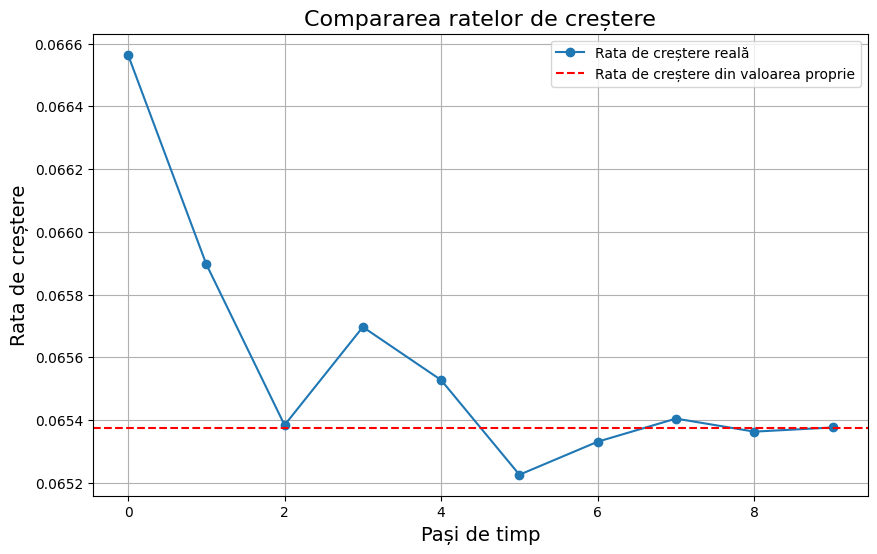


Compararea ratelor de creștere:
Rata de creștere estimată din valoarea proprie: 0.065376 per pas
Rata medie de creștere reală (din simulare): 0.065577 per pas

Tabelul populației absolute:
      An  Vârsta 0-10  Vârsta 10-20  Vârsta 20-30  Vârsta 30-40  Vârsta 40-50  \
0      0   152.000000    141.000000    132.000000    123.000000    114.000000   
10    10   162.615000    149.720000    140.436000    131.208000    121.770000   
20    20   173.058876    160.175775    149.121120    139.593384    129.895920   
30    30   184.054071    170.462993    159.535072    148.226393    138.197450   
40    40   196.440872    181.293260    169.781141    158.577861    146.744129   
50    50   209.248228    193.494259    180.568087    168.762454    156.992083   
60    60   222.710596    206.109504    192.720282    179.484678    167.074830   
70    70   237.450431    219.369937    205.285066    191.563961    177.689832   
80    80   252.993789    233.888675    218.492458    204.053356    189.648321   


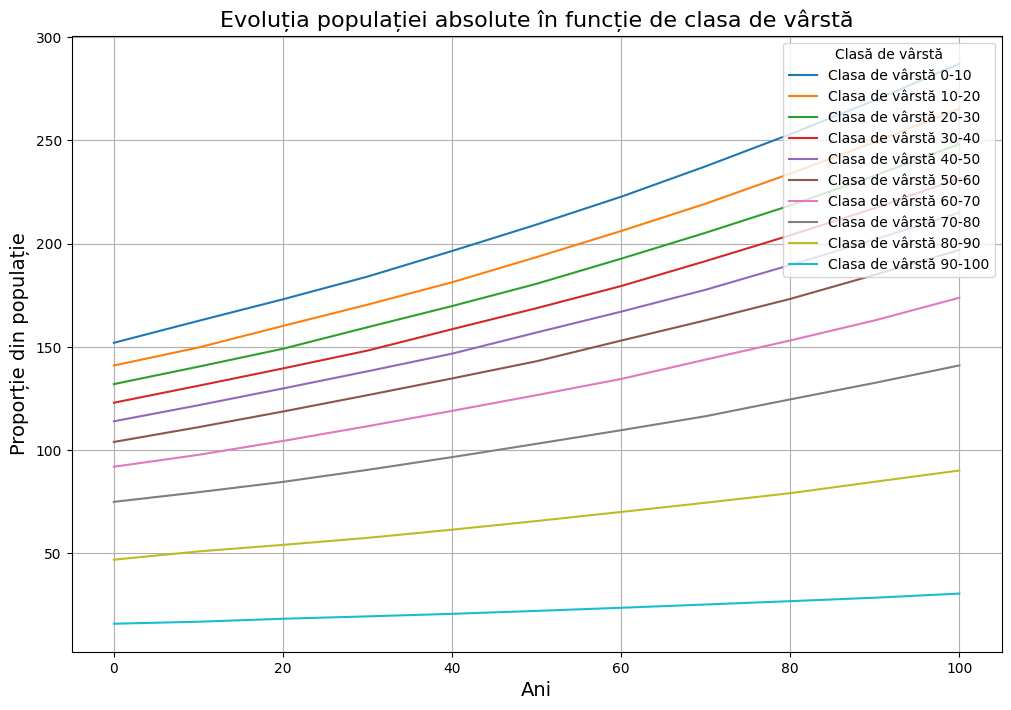

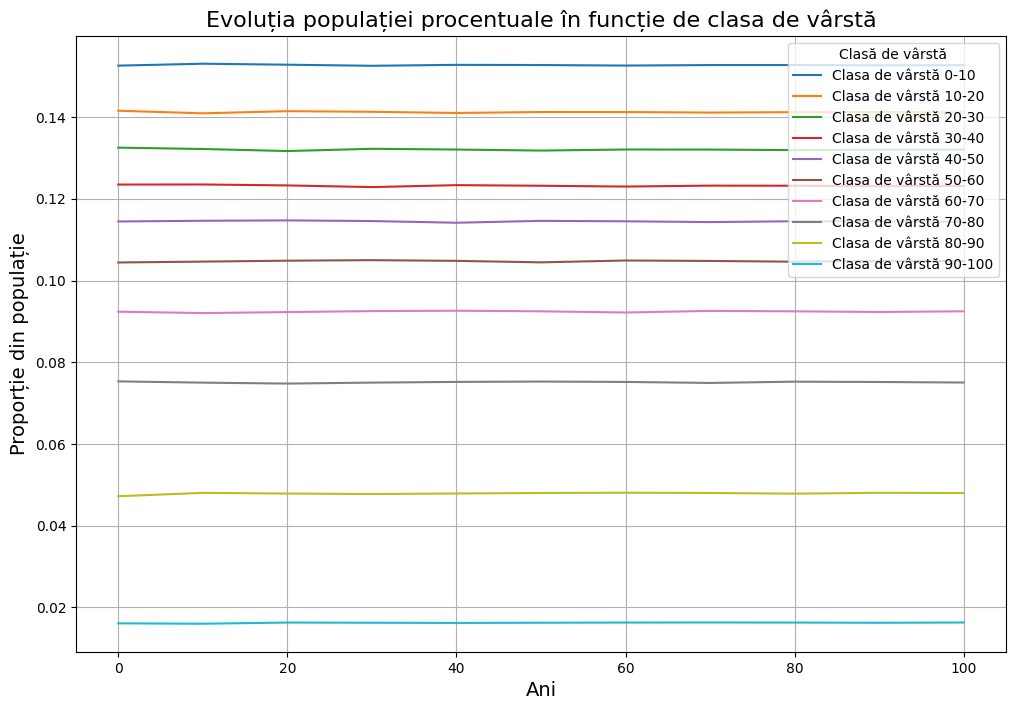

In [8]:
# Setarea parametrilor pentru simularea evoluției populației

max_age = 100
age_classes = 10
birth_rates = [0, 0.174, 0.782, 0.263, 0.022, 0, 0, 0, 0, 0]
survival_probs = [0.985, 0.996, 0.994, 0.990, 0.975, 0.940, 0.866, 0.680, 0.361]
initial_population = [152, 141, 132, 123, 114, 104, 92, 75, 47, 16]

# Simulăm evoluția populației pentru 100 de ani
absolute_populations, percentage_populations, transition_matrix = apply_population_model(max_age, age_classes, birth_rates, survival_probs, initial_population, 100)

# Comparăm metoda de calcul al valorilor proprii (metoda puterii vs. numpy)
compare_eigen_methods(transition_matrix)

# Comparăm ratele de creștere estimative și bazate pe simulare
compare_growth_rates(transition_matrix, absolute_populations)

# Afișăm tabelele populației
display_population_table(absolute_populations, percentage_populations, max_age, age_classes)

# Graficăm evoluția populației
plot_population_over_time(absolute_populations, max_age, age_classes, "Evoluția populației absolute în funcție de clasa de vârstă")
plot_population_over_time(percentage_populations, max_age, age_classes, "Evoluția populației procentuale în funcție de clasa de vârstă")
